In [3]:
import pandas as pd
from pymongo import MongoClient
import json
import os
 
client = MongoClient("mongodb://localhost:27017/")
db = client["airbnb_nyc"]
collection = db["listings"]

df = pd.read_excel("AB_NYC_2019.xlsx")

In [ ]:
df["last_review"] = df["last_review"].astype(str)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0) 
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")
 
records = df.to_dict(orient="records")
 
print(f"Inserting {len(records):,} records into MongoDB...")
collection.drop()                    
collection.insert_many(records)
 
count = collection.count_documents({})
print(f"Success {count:,} documents inserted into airbnb_nyc.listings")
 
collection.create_index("neighbourhood_group")
collection.create_index("room_type")
collection.create_index("price")
print("Indexes created")
 
client.close()

Inserting 48,895 records into MongoDB...
✅ Success! 48,895 documents inserted into airbnb_nyc.listings
✅ Indexes created


In [4]:
client = MongoClient("mongodb://localhost:27017/")
db = client["airbnb_nyc"]
collection = db["listings"]
 
os.makedirs("mapreduce_results", exist_ok=True)

In [6]:

pipeline_job1 = [
    {
        "$group": {
            "_id": "$neighbourhood_group",
            "total_listings": {"$sum": 1},
            "avg_price": {"$avg": "$price"},
            "min_price": {"$min": "$price"},
            "max_price": {"$max": "$price"},
            "avg_reviews": {"$avg": "$number_of_reviews"},
        }
    },
    {"$sort": {"total_listings": -1}},
]
 
results_job1 = list(collection.aggregate(pipeline_job1))
df_job1 = pd.DataFrame(results_job1).rename(columns={"_id": "borough"})
df_job1["avg_price"] = df_job1["avg_price"].round(2)
df_job1["avg_reviews"] = df_job1["avg_reviews"].round(2)
 
db["mapreduce_price_by_borough"].drop()
db["mapreduce_price_by_borough"].insert_many(df_job1.to_dict(orient="records"))
df_job1.to_csv("mapreduce_results/job1_price_by_borough.csv", index=False)
 
print(df_job1.to_string(index=False))
 
 

      borough  total_listings  avg_price  min_price  max_price  avg_reviews
    Manhattan           21661     196.88          0      10000        20.99
     Brooklyn           20104     124.38          0      10000        24.20
       Queens            5666      99.52         10      10000        27.70
        Bronx            1091      87.50          0       2500        26.00
Staten Island             373     114.81         13       5000        30.94


In [7]:
pipeline_job2 = [
    {
        "$group": {
            "_id": {
                "borough": "$neighbourhood_group",
                "room_type": "$room_type",
            },
            "count": {"$sum": 1},
            "avg_price": {"$avg": "$price"},
            "avg_availability": {"$avg": "$availability_365"},
        }
    },
    {"$sort": {"_id.borough": 1, "count": -1}},
]
 
results_job2 = list(collection.aggregate(pipeline_job2))
df_job2 = pd.DataFrame(results_job2)
df_job2["borough"] = df_job2["_id"].apply(lambda x: x["borough"])
df_job2["room_type"] = df_job2["_id"].apply(lambda x: x["room_type"])
df_job2 = df_job2.drop(columns=["_id"])
df_job2["avg_price"] = df_job2["avg_price"].round(2)
df_job2["avg_availability"] = df_job2["avg_availability"].round(2)
df_job2 = df_job2[["borough", "room_type", "count", "avg_price", "avg_availability"]]
 
db["mapreduce_roomtype_by_borough"].drop()
db["mapreduce_roomtype_by_borough"].insert_many(df_job2.to_dict(orient="records"))
df_job2.to_csv("mapreduce_results/job2_roomtype_by_borough.csv", index=False)
 
print(df_job2.to_string(index=False))

      borough       room_type  count  avg_price  avg_availability
        Bronx    Private room    652      66.79            171.33
        Bronx Entire home/apt    379     127.51            158.00
        Bronx     Shared room     60      59.80            154.22
     Brooklyn    Private room  10132      76.50             99.92
     Brooklyn Entire home/apt   9559     178.33             97.21
     Brooklyn     Shared room    413      50.53            178.01
    Manhattan Entire home/apt  13199     249.24            117.14
    Manhattan    Private room   7982     116.78            101.85
    Manhattan     Shared room    480      88.98            138.57
       Queens    Private room   3372      71.76            149.22
       Queens Entire home/apt   2096     147.05            132.27
       Queens     Shared room    198      69.02            192.19
Staten Island    Private room    188      62.29            226.36
Staten Island Entire home/apt    176     173.85            178.07
Staten Isl

In [8]:
pipeline_job3 = [
    {
        "$group": {
            "_id": "$host_id",
            "host_name": {"$first": "$host_name"},
            "listing_count": {"$sum": 1},
            "avg_price": {"$avg": "$price"},
            "total_reviews": {"$sum": "$number_of_reviews"},
        }
    },
    {"$sort": {"listing_count": -1}},
    {"$limit": 10},
]
 
results_job3 = list(collection.aggregate(pipeline_job3))
df_job3 = pd.DataFrame(results_job3).rename(columns={"_id": "host_id"})
df_job3["avg_price"] = df_job3["avg_price"].round(2)
 
db["mapreduce_top_hosts"].drop()
db["mapreduce_top_hosts"].insert_many(df_job3.to_dict(orient="records"))
df_job3.to_csv("mapreduce_results/job3_top_hosts.csv", index=False)
 
print(df_job3[["host_name", "listing_count", "avg_price"]].to_string(index=False))
 
client.close()

        host_name  listing_count  avg_price
     Sonder (NYC)            327     253.20
       Blueground            232     303.15
             Kara            121     277.53
           Kazuya            103      43.83
   Jeremy & Laura             96     208.96
           Sonder             96     213.03
Corporate Housing             91     146.24
              Ken             87     215.44
          Pranjal             65     290.23
             Mike             52     103.08


Connecting to MongoDB...
Loaded 48,895 listings
  → Price Distribution
  → Avg Price by Borough
  → Room Type Stacked
  → Price by Room Type & Borough
  → Price vs Reviews Scatter
  → Availability Box Plot
  → Price Heatmap
  → Top 10 Hosts


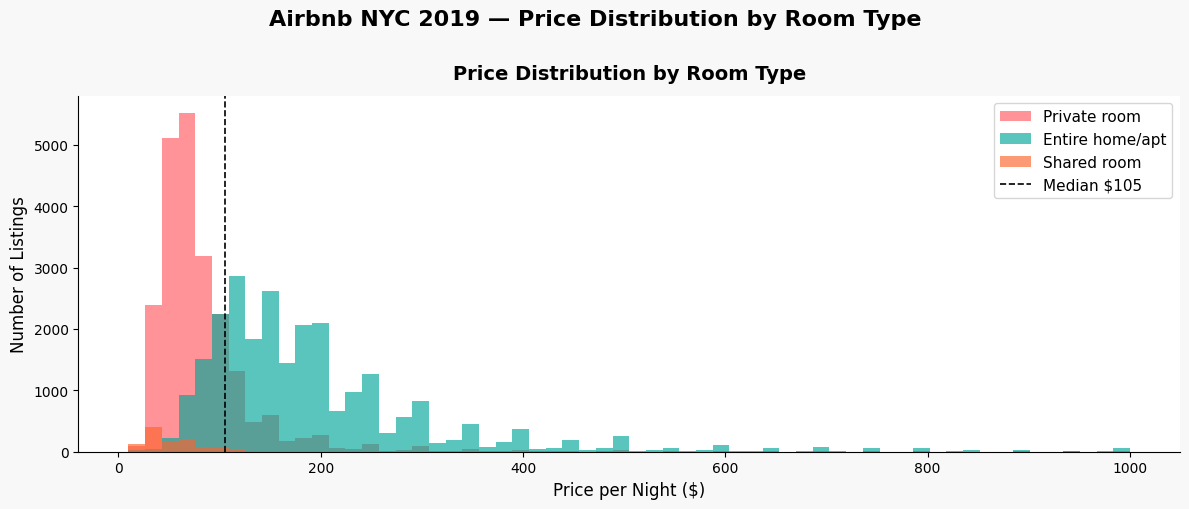

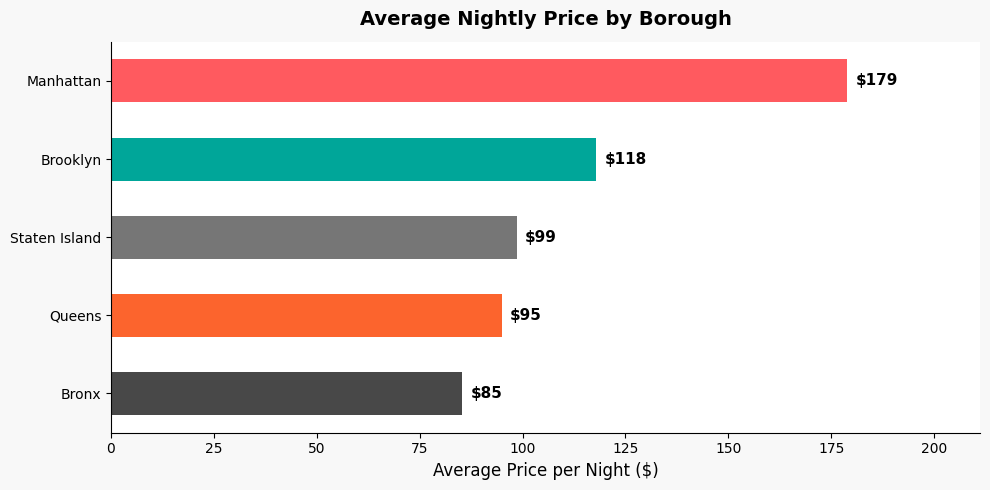

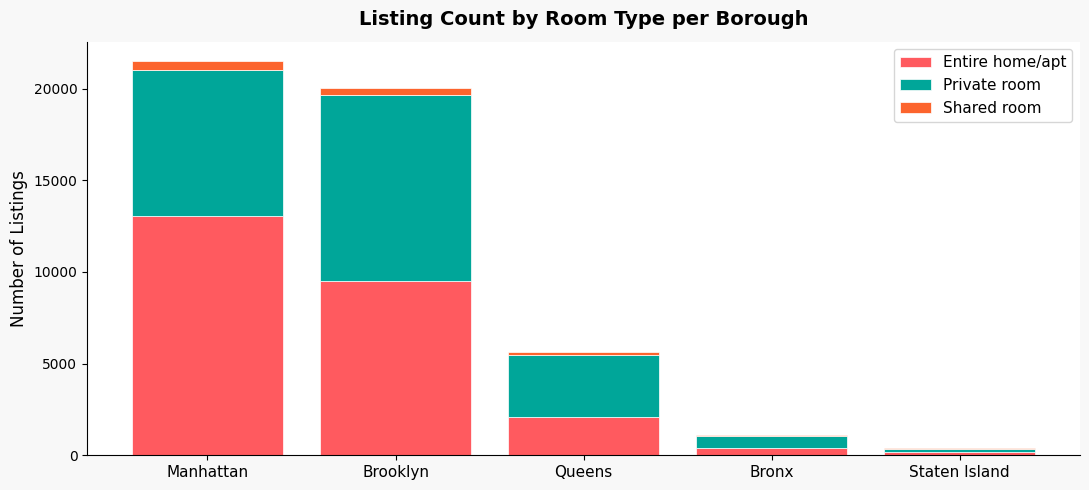

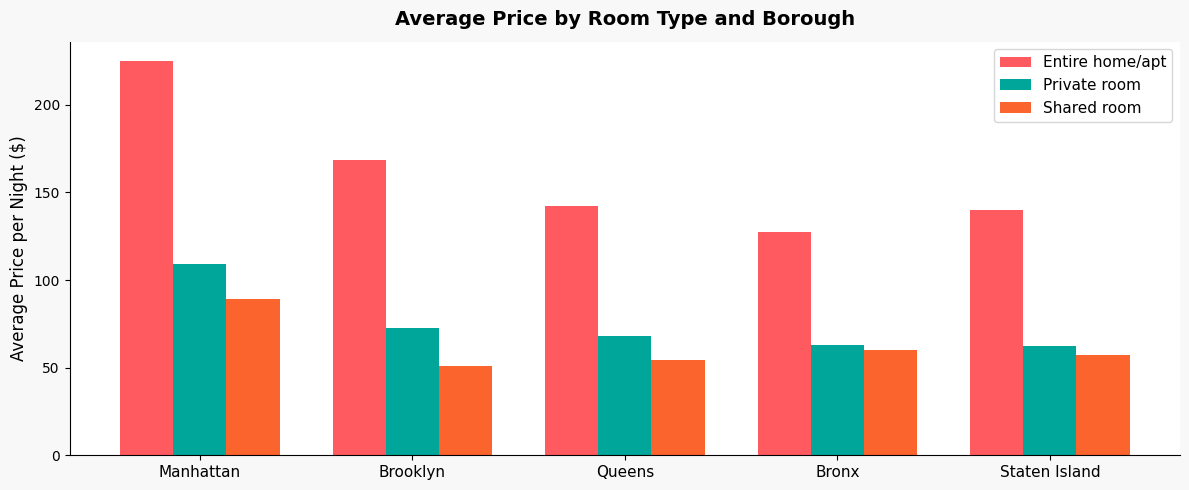

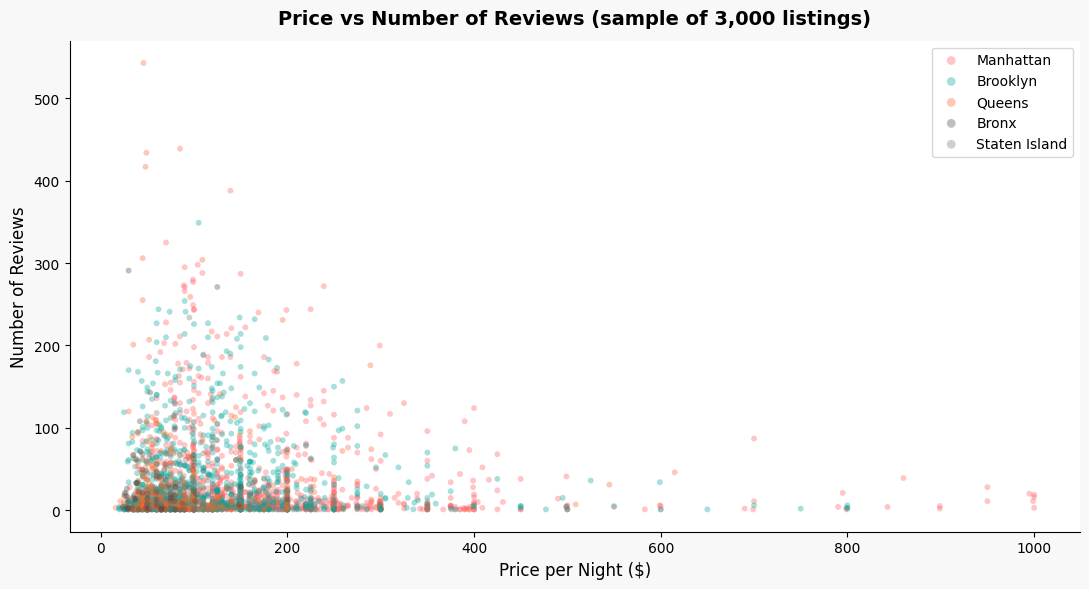

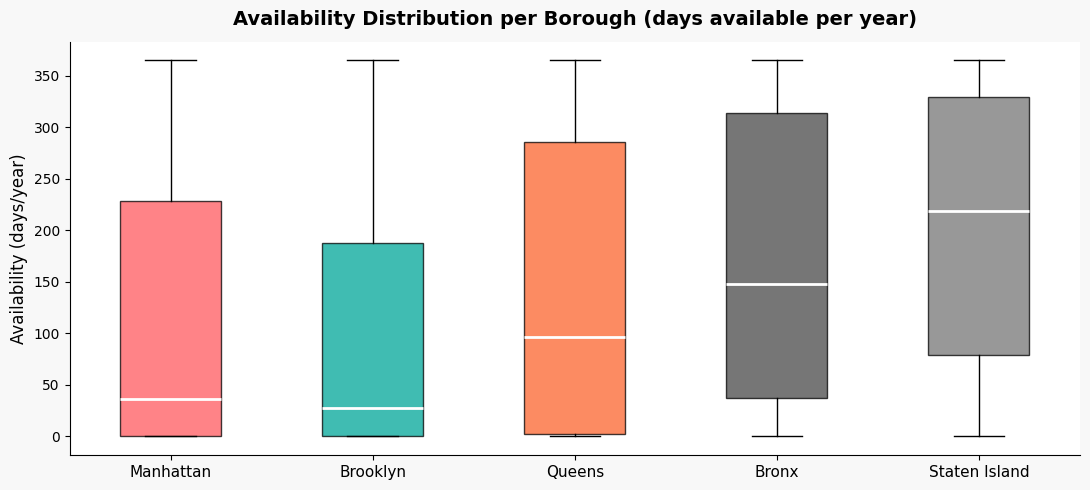

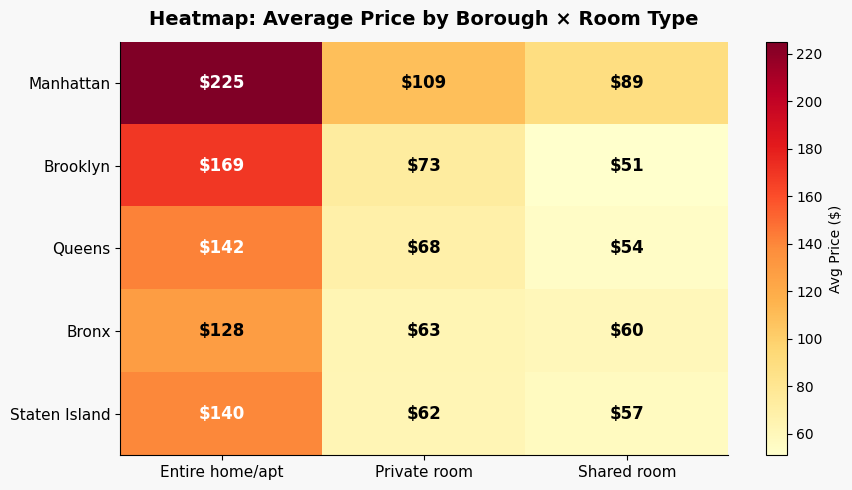

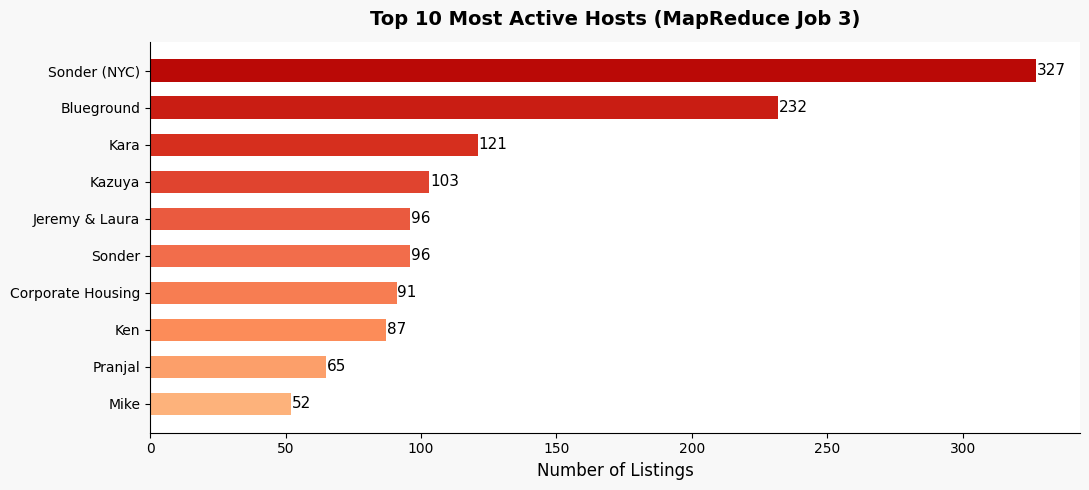

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import warnings
warnings.filterwarnings("ignore")
 
COLORS = ["#FF5A5F", "#00A699", "#FC642D", "#484848", "#767676"]
BOROUGH_COLORS = {
    "Manhattan":    "#FF5A5F",
    "Brooklyn":     "#00A699",
    "Queens":       "#FC642D",
    "Bronx":        "#484848",
    "Staten Island":"#767676",
}
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize":  14,
    "axes.titleweight":"bold",
    "axes.titlepad":   12,
    "figure.facecolor":"#f8f8f8",
    "axes.facecolor":  "white",
})
 
# Load data from MongoDB 
print("Connecting to MongoDB...")
client = MongoClient("mongodb://localhost:27017/")
db = client["airbnb_nyc"]
 
df        = pd.DataFrame(list(db["listings"].find({}, {"_id": 0})))
df_borough= pd.DataFrame(list(db["mapreduce_price_by_borough"].find({}, {"_id": 0})))
df_rt     = pd.DataFrame(list(db["mapreduce_roomtype_by_borough"].find({}, {"_id": 0})))
client.close()
print(f"Loaded {len(df):,} listings")
 
df_clean = df[df["price"].between(10, 1000)].copy()
boroughs = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

# CHART 1 — Price Distribution by Room Type (Histogram)
def chart1_price_distribution():
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle("Airbnb NYC 2019 — Price Distribution by Room Type",
                 fontsize=16, fontweight="bold", y=1.01)
 
    room_types = df_clean["room_type"].unique()
    for i, rt in enumerate(room_types):
        subset = df_clean[df_clean["room_type"] == rt]["price"]
        ax.hist(subset, bins=60, alpha=0.65, color=COLORS[i],
                label=rt, edgecolor="none")
 
    ax.set_xlabel("Price per Night ($)", fontsize=12)
    ax.set_ylabel("Number of Listings", fontsize=12)
    ax.set_title("Price Distribution by Room Type")
    ax.legend(fontsize=11)
    ax.axvline(df_clean["price"].median(), color="black",
               linestyle="--", linewidth=1.2, label=f"Median ${df_clean['price'].median():.0f}")
    ax.legend(fontsize=11)
    fig.tight_layout()
    return fig
 
 
# CHART 2 — Average Price by Borough (Horizontal Bar)
def chart2_avg_price_borough():
    fig, ax = plt.subplots(figsize=(10, 5))
 
    data = (df_clean.groupby("neighbourhood_group")["price"]
            .mean().reindex(boroughs).sort_values())
    bar_colors = [BOROUGH_COLORS[b] for b in data.index]
 
    bars = ax.barh(data.index, data.values, color=bar_colors,
                   edgecolor="none", height=0.55)
 
    for bar, val in zip(bars, data.values):
        ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
                f"${val:.0f}", va="center", fontsize=11, fontweight="bold")
 
    ax.set_xlabel("Average Price per Night ($)", fontsize=12)
    ax.set_title("Average Nightly Price by Borough")
    ax.set_xlim(0, data.max() * 1.18)
    fig.tight_layout()
    return fig
 
 
# CHART 3 — Room Type Distribution per Borough (Stacked Bar)
def chart3_roomtype_stacked():
    fig, ax = plt.subplots(figsize=(11, 5))
 
    pivot = (df_clean.groupby(["neighbourhood_group", "room_type"])
             .size().unstack(fill_value=0)
             .reindex(boroughs))
 
    bottom = np.zeros(len(boroughs))
    for i, rt in enumerate(pivot.columns):
        ax.bar(boroughs, pivot[rt].values, bottom=bottom,
               color=COLORS[i], label=rt, edgecolor="white", linewidth=0.5)
        bottom += pivot[rt].values
 
    ax.set_ylabel("Number of Listings", fontsize=12)
    ax.set_title("Listing Count by Room Type per Borough")
    ax.legend(fontsize=11, loc="upper right")
    ax.tick_params(axis="x", labelsize=11)
    fig.tight_layout()
    return fig
 
 
# CHART 4 — Price by Room Type per Borough (Grouped Bar)
def chart4_price_roomtype_grouped():
    fig, ax = plt.subplots(figsize=(12, 5))
 
    pivot = (df_clean.groupby(["neighbourhood_group", "room_type"])["price"]
             .mean().unstack().reindex(boroughs))
 
    x = np.arange(len(boroughs))
    n = len(pivot.columns)
    width = 0.25
 
    for i, rt in enumerate(pivot.columns):
        offset = (i - n / 2 + 0.5) * width
        bars = ax.bar(x + offset, pivot[rt].values, width=width,
                      color=COLORS[i], label=rt, edgecolor="none")
 
    ax.set_xticks(x)
    ax.set_xticklabels(boroughs, fontsize=11)
    ax.set_ylabel("Average Price per Night ($)", fontsize=12)
    ax.set_title("Average Price by Room Type and Borough")
    ax.legend(fontsize=11)
    fig.tight_layout()
    return fig

# CHART 5 — Price vs Number of Reviews (Scatter)
def chart5_price_vs_reviews():
    fig, ax = plt.subplots(figsize=(11, 6))
 
    sample = (df_clean[df_clean["number_of_reviews"] > 0]
              .sample(3000, random_state=42))
 
    for borough in boroughs:
        sub = sample[sample["neighbourhood_group"] == borough]
        ax.scatter(sub["price"], sub["number_of_reviews"],
                   alpha=0.35, s=18, color=BOROUGH_COLORS[borough],
                   label=borough, edgecolors="none")
 
    ax.set_xlabel("Price per Night ($)", fontsize=12)
    ax.set_ylabel("Number of Reviews", fontsize=12)
    ax.set_title("Price vs Number of Reviews (sample of 3,000 listings)")
    ax.legend(fontsize=10, markerscale=1.5)
    fig.tight_layout()
    return fig

# CHART 6 — Availability Distribution per Borough (Box Plot)
def chart6_availability_boxplot():
    fig, ax = plt.subplots(figsize=(11, 5))
 
    data_by_borough = [df_clean[df_clean["neighbourhood_group"] == b]["availability_365"].values
                       for b in boroughs]
 
    bp = ax.boxplot(data_by_borough, labels=boroughs, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
 
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
 
    ax.set_ylabel("Availability (days/year)", fontsize=12)
    ax.set_title("Availability Distribution per Borough (days available per year)")
    ax.tick_params(axis="x", labelsize=11)
    fig.tight_layout()
    return fig
 
# CHART 7 — Heatmap: Avg Price by Borough × Room Type
def chart7_heatmap():
    fig, ax = plt.subplots(figsize=(9, 5))
 
    pivot = (df_clean.groupby(["neighbourhood_group", "room_type"])["price"]
             .mean().unstack().reindex(boroughs).round(0))
 
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="Avg Price ($)")
 
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticks(range(len(boroughs)))
    ax.set_yticklabels(boroughs, fontsize=11)
    ax.set_title("Heatmap: Average Price by Borough × Room Type")
 
    for i in range(len(boroughs)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f"${val:.0f}", ha="center", va="center",
                    fontsize=12, fontweight="bold",
                    color="white" if val > pivot.values.max() * 0.6 else "black")
 
    fig.tight_layout()
    return fig
 
# CHART 8 — Top 10 Most Active Hosts (from MapReduce Job 3)
def chart8_top_hosts():
    client2 = MongoClient("mongodb://localhost:27017/")
    df_hosts = pd.DataFrame(list(
        client2["airbnb_nyc"]["mapreduce_top_hosts"].find({}, {"_id": 0})
    ))
    client2.close()
 
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = plt.cm.OrRd(np.linspace(0.4, 0.85, len(df_hosts)))[::-1]
    bars = ax.barh(df_hosts["host_name"], df_hosts["listing_count"],
                   color=colors, edgecolor="none", height=0.6)
 
    for bar, val in zip(bars, df_hosts["listing_count"]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=11)
 
    ax.set_xlabel("Number of Listings", fontsize=12)
    ax.set_title("Top 10 Most Active Hosts (MapReduce Job 3)")
    ax.invert_yaxis()
    fig.tight_layout()
    return fig
 

# BUILD ALL CHARTS & SAVE TO PDF
charts = [
    ("Price Distribution",          chart1_price_distribution),
    ("Avg Price by Borough",        chart2_avg_price_borough),
    ("Room Type Stacked",           chart3_roomtype_stacked),
    ("Price by Room Type & Borough",chart4_price_roomtype_grouped),
    ("Price vs Reviews Scatter",    chart5_price_vs_reviews),
    ("Availability Box Plot",       chart6_availability_boxplot),
    ("Price Heatmap",               chart7_heatmap),
    ("Top 10 Hosts",                chart8_top_hosts),
]
 
PDF_FILE = "airbnb_nyc_analysis.pdf"
 
with PdfPages(PDF_FILE) as pdf:
    # Cover page
    cover = plt.figure(figsize=(12, 7))
    cover.patch.set_facecolor("#FF5A5F")
    cover.text(0.5, 0.60, "Airbnb NYC 2019",
               ha="center", va="center", fontsize=38,
               fontweight="bold", color="white", transform=cover.transFigure)
    cover.text(0.5, 0.48, "Data Analysis Report",
               ha="center", va="center", fontsize=22,
               color="white", alpha=0.9, transform=cover.transFigure)
    cover.text(0.5, 0.36, f"{len(df):,} listings  ·  5 boroughs  ·  8 charts",
               ha="center", va="center", fontsize=14,
               color="white", alpha=0.75, transform=cover.transFigure)
    cover.text(0.5, 0.22, "Tools: Python · MongoDB · Matplotlib · MapReduce",
               ha="center", va="center", fontsize=12,
               color="white", alpha=0.65, transform=cover.transFigure)
    pdf.savefig(cover, bbox_inches="tight")
    plt.close(cover)
 
    for name, fn in charts:
        print(f"  → {name}")
        fig = fn()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
 
for name, fn in charts:
    fn()
plt.show()